In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
!pip install pycountry

In [4]:
from math import nan
def strip(a_column):
  values = set()

  for i in range(a_column.shape[0]):
    if pd.isna(a_column.iloc[i]):
      continue

    vals = str(a_column.iloc[i]).split(",")

    for val in vals:
      clean_val = val.strip()
      if clean_val:
        values.add(clean_val)

  return list(values)

def complementary(artists, node_name : str):
  G = nx.Graph()
  artists = artists[["artist", node_name]]
  artists = artists.dropna()
  exhibitions = strip(artists[node_name])
  if "Unknown" in exhibitions:
    exhibitions.remove("Unknown")
  G.add_nodes_from(exhibitions)

  exhibition_artist = {}
  for index, row in artists.iterrows():
    exhibition_artist[row["artist"]] = [exhibition.strip() for exhibition in row[node_name].split(",") if exhibition.strip().lower() != "unknown"]
  for artist in exhibition_artist.keys():
    for exhibition1 in exhibition_artist[artist]:
      for exhibition2 in exhibition_artist[artist]:
        if exhibition1 != exhibition2 and not G.has_edge(exhibition1, exhibition2):
          G.add_edge(exhibition1, exhibition2)
  return G

from collections import Counter

def complementary_top(artists, node_name: str, top=20):
    G = nx.Graph()
    artists = artists[["artist", node_name]].dropna()
    exhibition_artist = {}
    all_exhibitions = []

    for _, row in artists.iterrows():
        exhibitions = [ex.strip()for ex in row[node_name].split(",")if ex.strip() and ex.strip().lower() != "unknown"]
        exhibition_artist[row["artist"]] = exhibitions
        all_exhibitions.extend(exhibitions)

    top_exhibitions = set([ex for ex, _ in Counter(all_exhibitions).most_common(top)])

    for artist in exhibition_artist:
        exhibition_artist[artist] = [ex for ex in exhibition_artist[artist] if ex in top_exhibitions]

    G.add_nodes_from(top_exhibitions)

    for exhibitions in exhibition_artist.values():
        for i in range(len(exhibitions)):
            for j in range(i + 1, len(exhibitions)):
                ex1, ex2 = exhibitions[i], exhibitions[j]
                if not G.has_edge(ex1, ex2):
                    G.add_edge(ex1, ex2)

    return G

def visualize_complementary_graph(G, figsize=(10, 8), title = "Complementary" , node_size=800, font_size=9, label = False):
    plt.figure(figsize=figsize)

    pos = nx.spring_layout(G, k=0.5, iterations=50)

    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="skyblue", edgecolors="black")
    nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.2)
    if label:
      nx.draw_networkx_labels(G, pos, font_size=font_size)

    plt.title(title)
    plt.axis("off")
    plt.show()

def visualize_complementary_graph_communities(G, figsize=(10, 8), title="Complementary", node_size=800, font_size=9, label=False):

    plt.figure(figsize=figsize)

    communities = nx.community.greedy_modularity_communities(G)

    supergraph = nx.cycle_graph(len(communities))
    superpos = nx.spring_layout(supergraph, scale=2, seed=429)

    centers = list(superpos.values())
    pos = {}
    for center, comm in zip(centers, communities):
        pos.update(nx.spring_layout(nx.subgraph(G, comm), center=center, seed=1430))

    cmap = plt.cm.get_cmap("tab10", len(communities))

    for i, nodes in enumerate(communities):
        nx.draw_networkx_nodes(
            G,
            pos=pos,
            nodelist=nodes,
            node_color=[cmap(i)],
            node_size=node_size
        )

    nx.draw_networkx_edges(G, pos=pos)

    if label:
        nx.draw_networkx_labels(G, pos, font_size=font_size)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Country generation
cols = [
    "geonameid", "name", "asciiname", "alternatenames",
    "latitude", "longitude", "feature_class", "feature_code",
    "country_code", "cc2", "admin1", "admin2", "admin3", "admin4",
    "population", "elevation", "dem", "timezone", "modification_date"
]

geo = pd.read_csv(
    "cities15000.txt",
    sep="\t",
    names=cols,
    encoding="latin-1",
    on_bad_lines="skip",
    low_memory=False
)

city_to_country = dict(
    zip(geo["name"].str.lower(), geo["country_code"])
)

import pycountry

def code_to_country(code):
    try:
        return pycountry.countries.get(alpha_2=code).name
    except:
        return None

def get_country(city):
    if pd.isna(city):
        return None

    city = str(city).strip()

    if len(city) == 2:
        return "United States"

    city_lower = city.lower()

    for country in pycountry.countries:
        if city_lower == country.name.lower():
            return country.name

    code = city_to_country.get(city_lower)
    if code is None:
        return None

    return code_to_country(code)

def skeletonize_graph(G):
    edges = list(G.edges())

    edges_to_remove = []

    for u, v in edges:
        G.remove_edge(u, v)
        try:
            still_connected = nx.has_path(G, u, v)
        except nx.NetworkXError:
            still_connected = False

        if still_connected:
            edges_to_remove.append((u, v))
        else:
            G.add_edge(u, v)
    G.remove_edges_from(edges_to_remove)

    return G

In [5]:
url = "https://raw.githubusercontent.com/me9hanics/PainterPalette/main/datasets/artists.csv"
artists = pd.read_csv(url)

artists["PaintingsExhibitedAtCountries"] = artists["PaintingsExhibitedAt"]

for i in range(artists.shape[0]):
    if pd.isna(artists.loc[i, "PaintingsExhibitedAt"]):
        continue

    cities = artists.loc[i, "PaintingsExhibitedAt"].split(",")
    cities = [city.strip() for city in cities]

    countries = [get_country(city) for city in cities]
    countries = [c for c in countries if c is not None]

    artists.loc[i, "PaintingsExhibitedAtCountries"] = ", ".join(countries)

artists_14c = artists[(artists['birth_year'] >= 1300) & (artists['birth_year'] < 1400)]
artists_15c = artists[(artists['birth_year'] >= 1400) & (artists['birth_year'] < 1500)]
artists_16c = artists[(artists['birth_year'] >= 1500) & (artists['birth_year'] < 1600)]
artists_17c = artists[(artists['birth_year'] >= 1600) & (artists['birth_year'] < 1700)]
artists_18c = artists[(artists['birth_year'] >= 1700) & (artists['birth_year'] < 1800)]
artists_19c = artists[(artists['birth_year'] >= 1800) & (artists['birth_year'] < 1900)]
artists_20c = artists[(artists['birth_year'] >= 1900) & (artists['birth_year'] < 2100)] # also includes 21st-century artists since they are so sparse
print(artists_14c.shape)
print(artists_15c.shape)
print(artists_16c.shape)
print(artists_17c.shape)
print(artists_18c.shape)
print(artists_19c.shape)
print(artists_20c.shape)

(65, 31)
(289, 31)
(526, 31)
(759, 31)
(1124, 31)
(3170, 31)
(3418, 31)


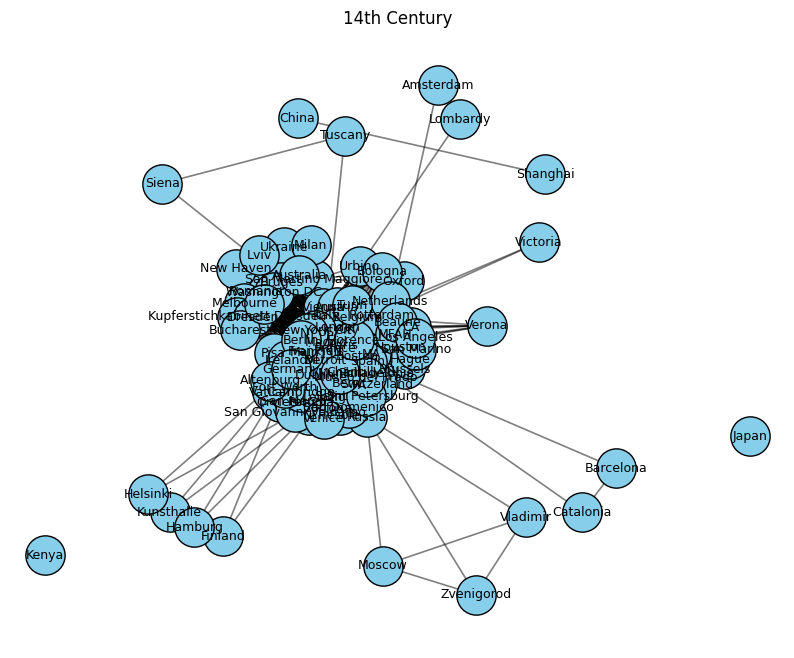

In [6]:
visualize_complementary_graph(complementary(artists_14c, "PaintingsExhibitedAt"), title = "14th Century", label = True)

/tmp/ipykernel_8805/840254424.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(communities))


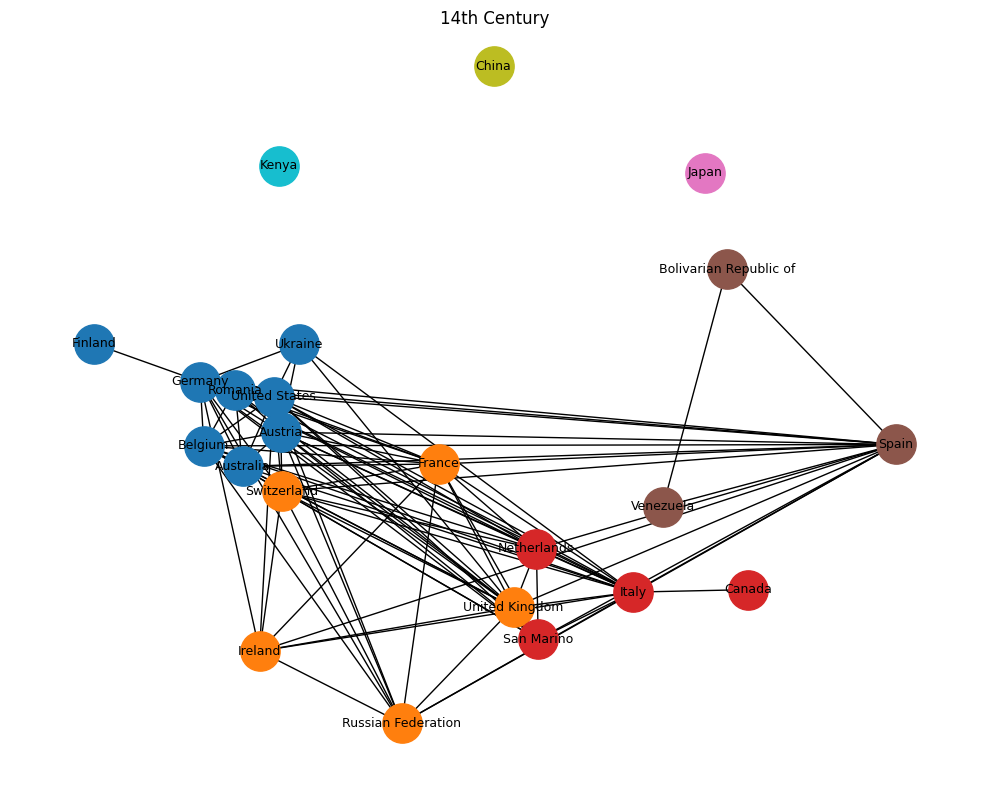

In [7]:
visualize_complementary_graph_communities(complementary(artists_14c, "PaintingsExhibitedAtCountries"), title = "14th Century", label = True)

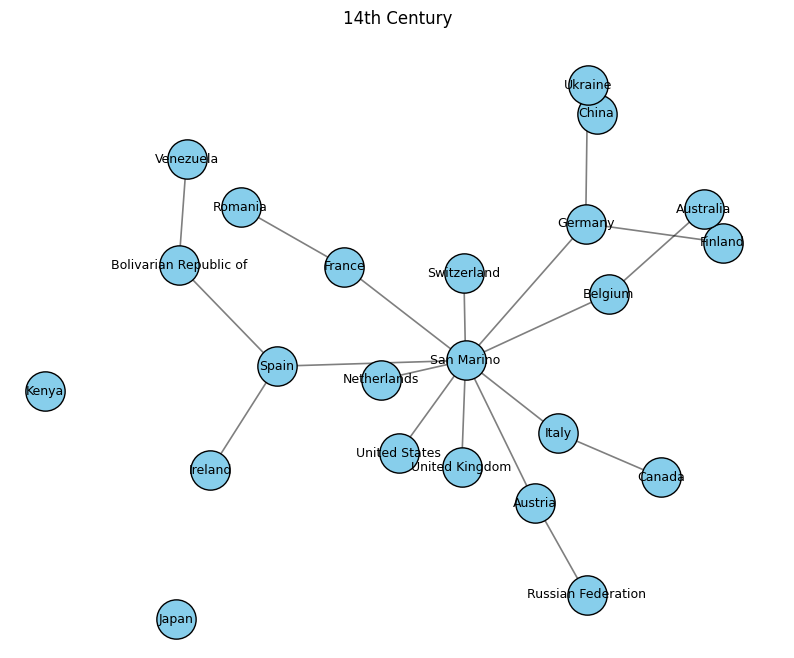

In [8]:
visualize_complementary_graph(skeletonize_graph(complementary(artists_14c, "PaintingsExhibitedAtCountries")), title = "14th Century", label = True)

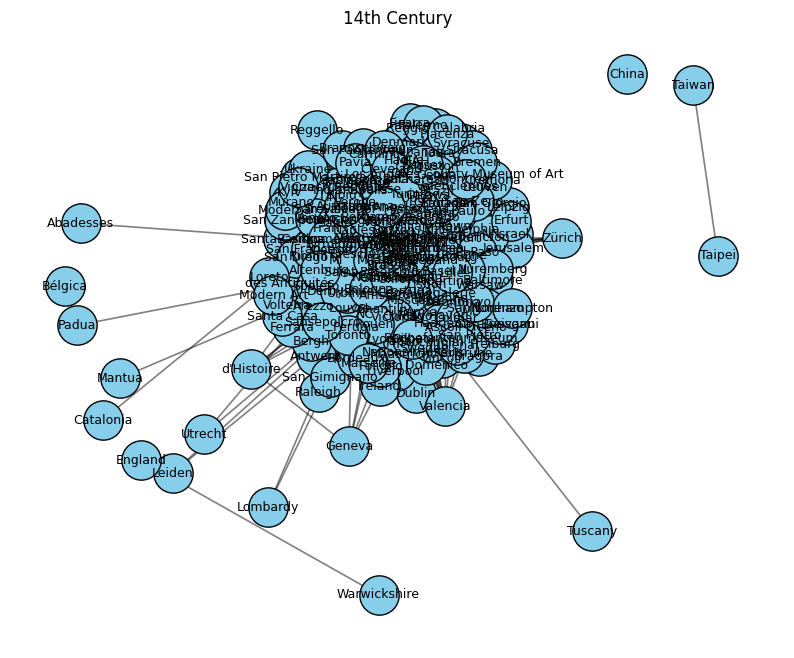

In [9]:
visualize_complementary_graph(complementary(artists_15c, "PaintingsExhibitedAt"), title = "14th Century", label = True)

/tmp/ipykernel_8805/840254424.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(communities))


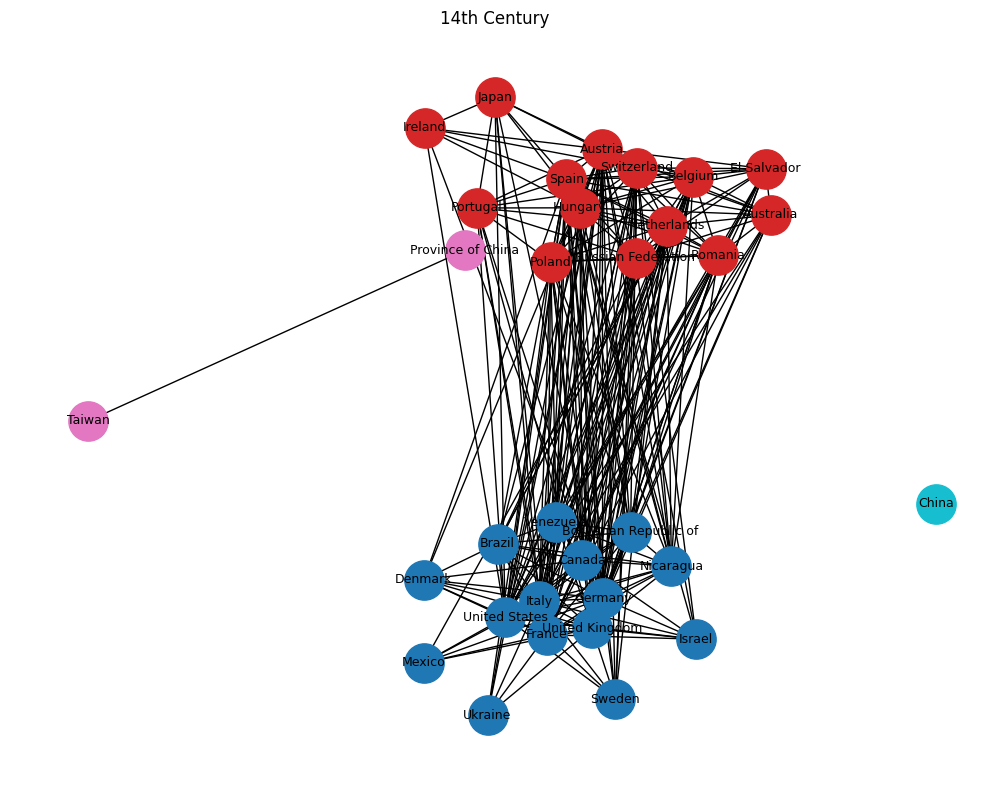

In [10]:
visualize_complementary_graph_communities(complementary(artists_15c, "PaintingsExhibitedAtCountries"), title = "14th Century", label = True)

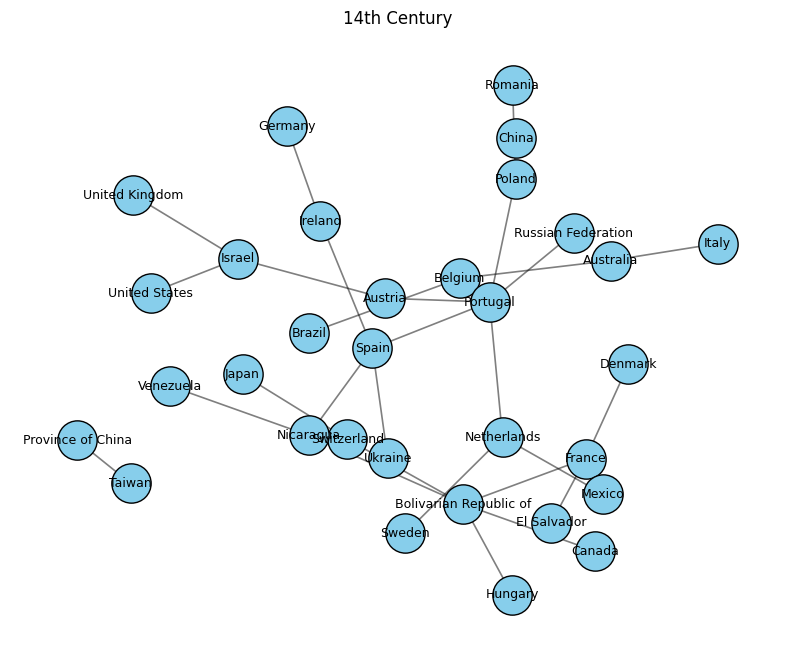

In [11]:
visualize_complementary_graph(skeletonize_graph(complementary(artists_15c, "PaintingsExhibitedAtCountries")), title = "14th Century", label = True)

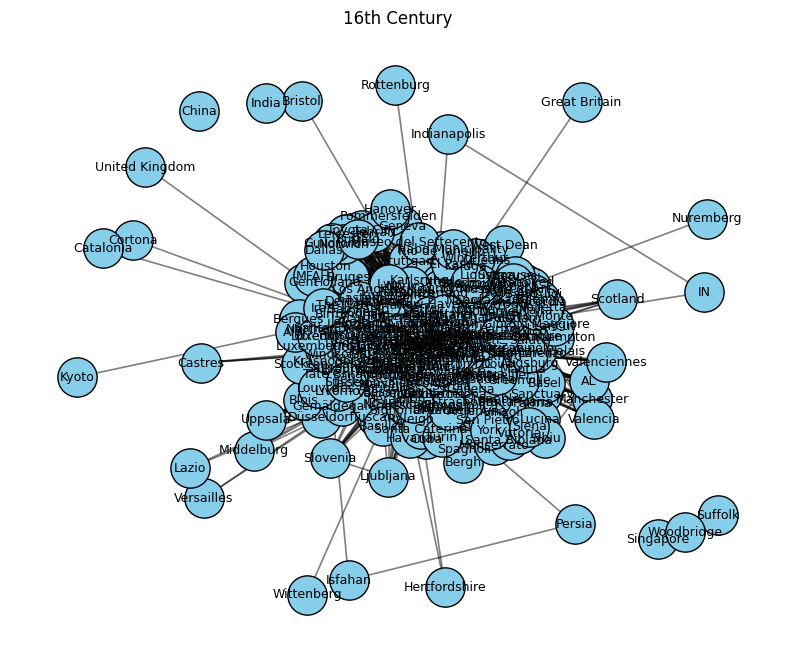

In [12]:
visualize_complementary_graph(complementary(artists_16c, "PaintingsExhibitedAt"), title = "16th Century", label = True)

/tmp/ipykernel_8805/840254424.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(communities))


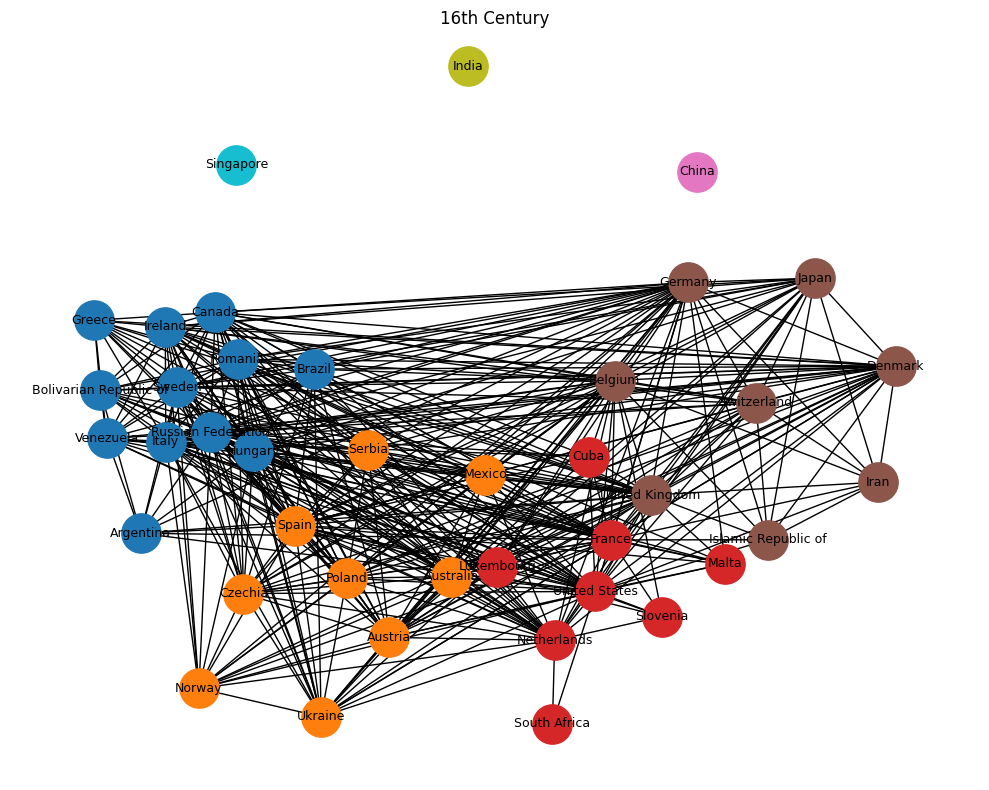

In [13]:
visualize_complementary_graph_communities(complementary(artists_16c, "PaintingsExhibitedAtCountries"), title = "16th Century", label = True)

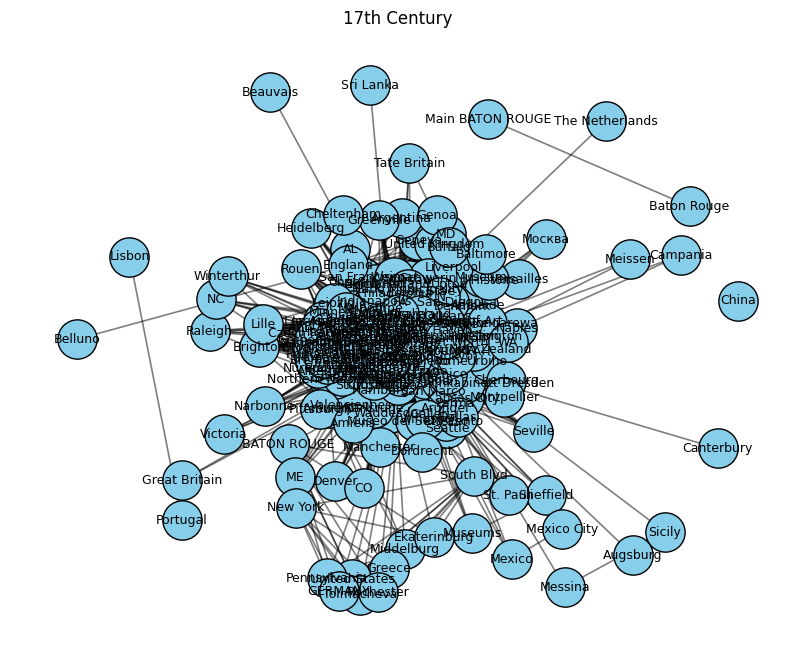

In [14]:
visualize_complementary_graph(complementary(artists_17c, "PaintingsExhibitedAt"), title = "17th Century", label = True)

/tmp/ipykernel_8805/840254424.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(communities))


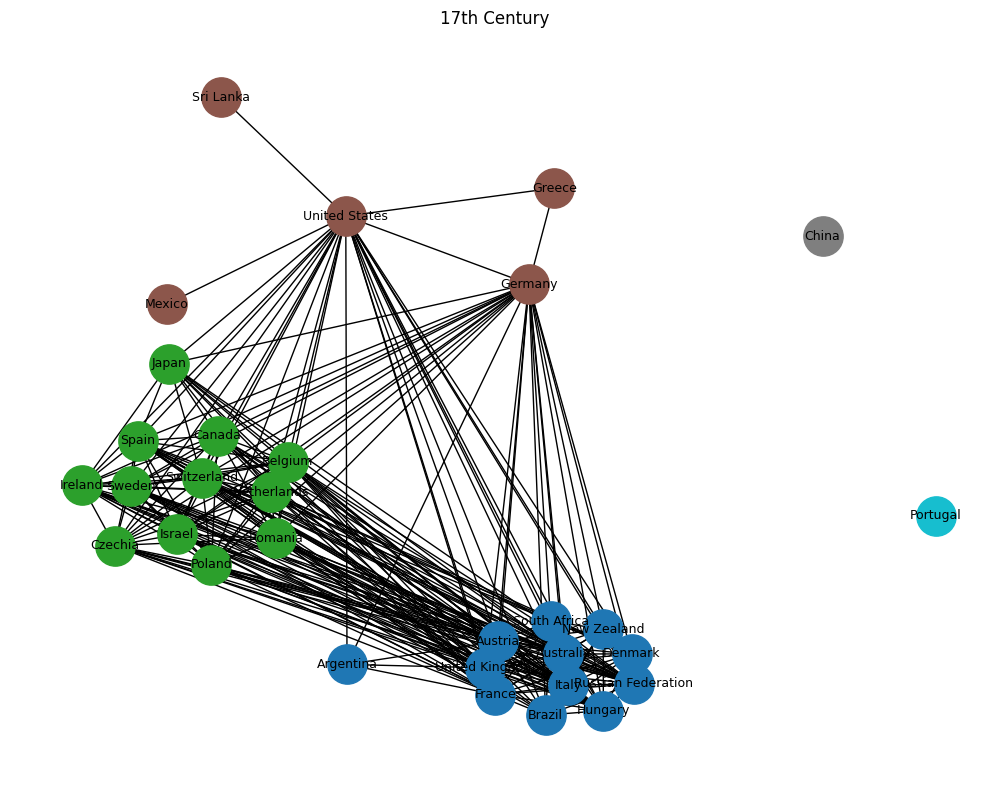

In [15]:
visualize_complementary_graph_communities(complementary(artists_17c, "PaintingsExhibitedAtCountries"), title = "17th Century", label = True)

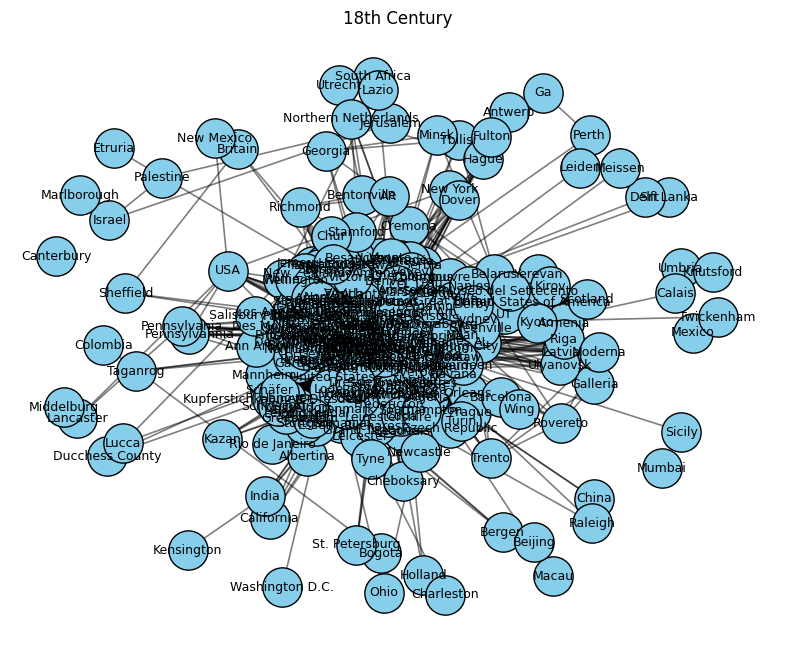

In [16]:
visualize_complementary_graph(complementary(artists_18c, "PaintingsExhibitedAt"), title = "18th Century", label = True)

/tmp/ipykernel_8805/840254424.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(communities))


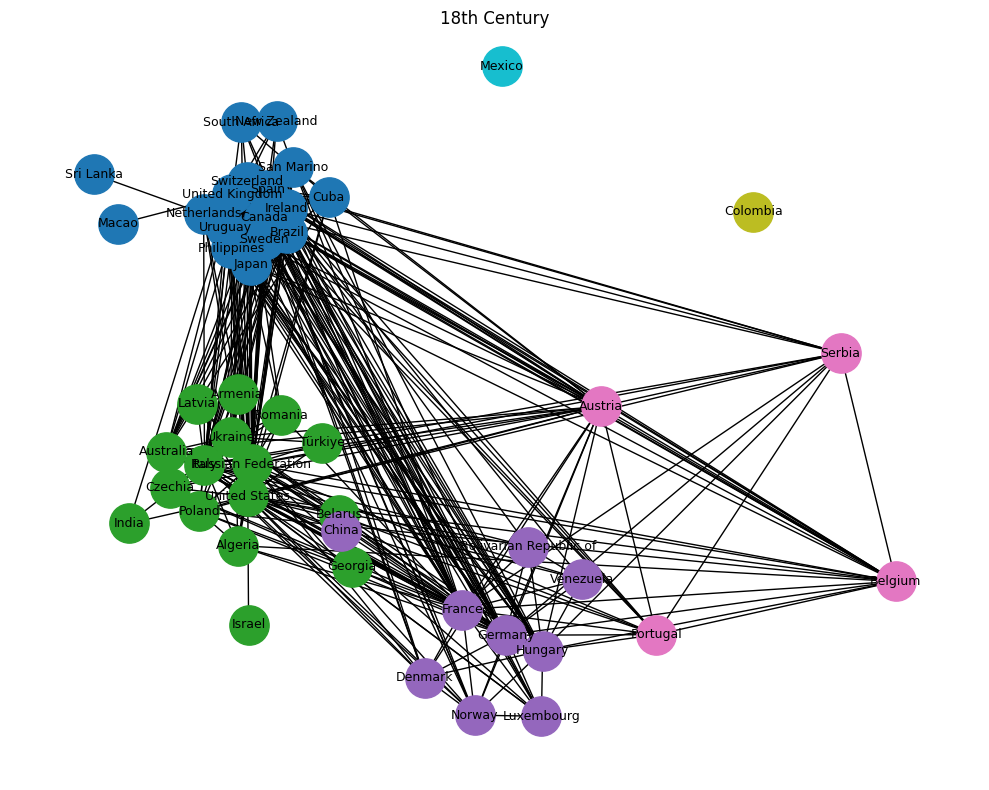

In [17]:
visualize_complementary_graph_communities(complementary(artists_18c, "PaintingsExhibitedAtCountries"), title = "18th Century", label = True)

/tmp/ipykernel_8805/840254424.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(communities))


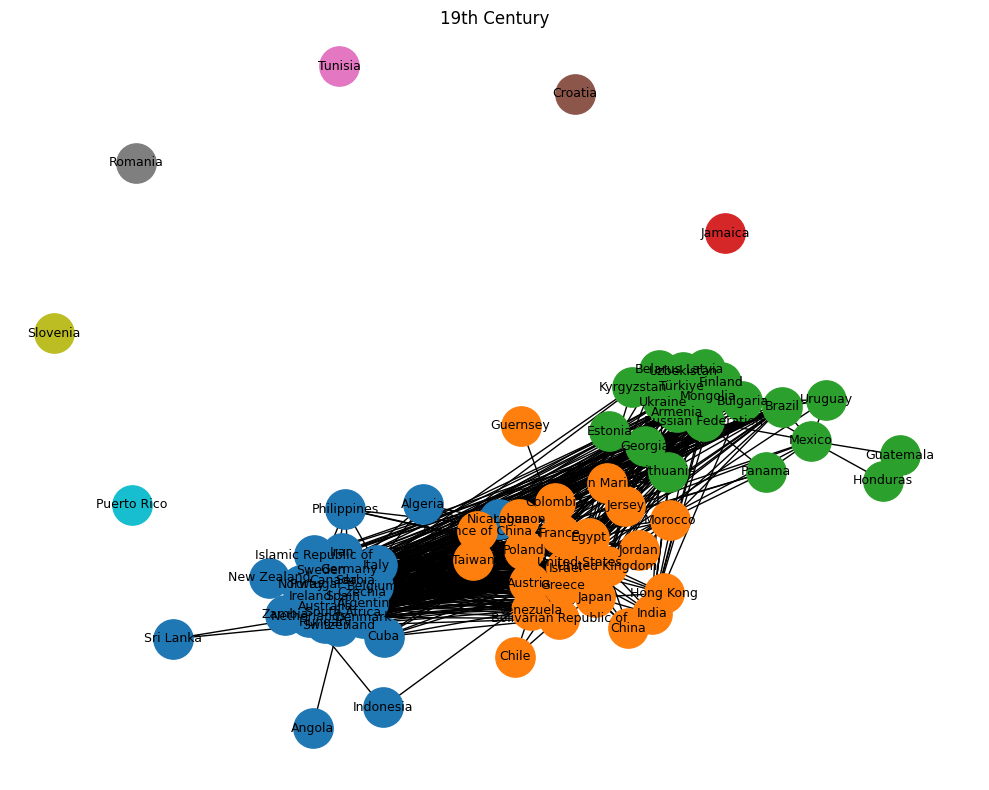

In [18]:
visualize_complementary_graph_communities(complementary(artists_19c, "PaintingsExhibitedAtCountries"), title = "19th Century", label = True)

/tmp/ipykernel_8805/840254424.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(communities))


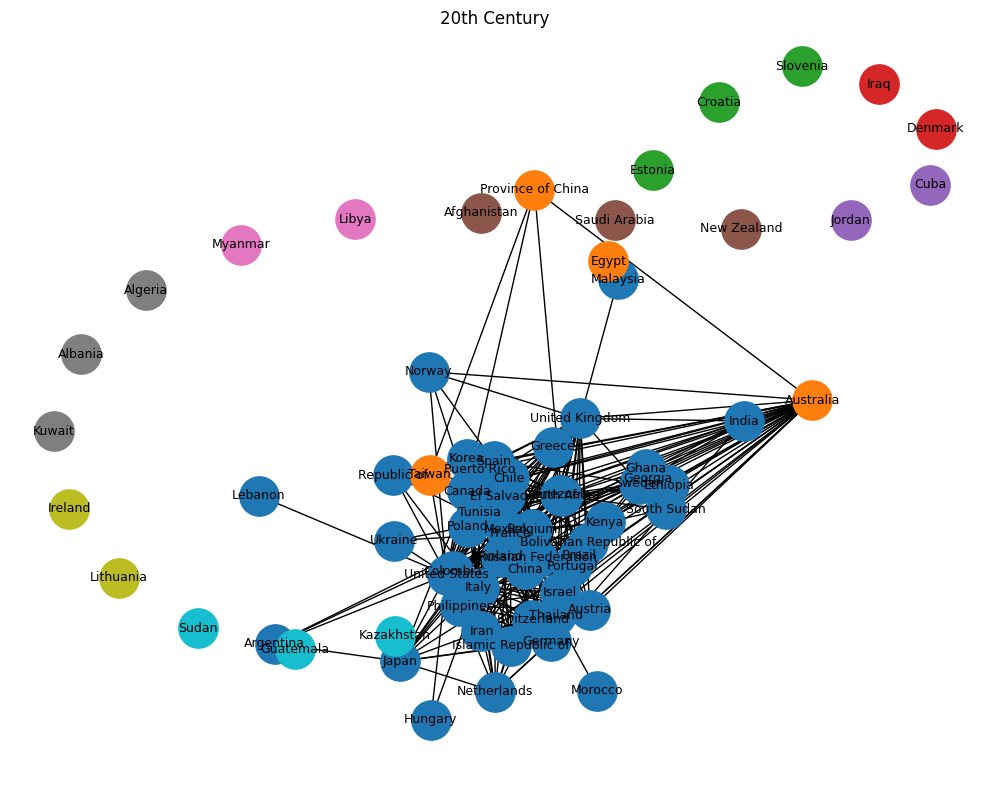

In [19]:
visualize_complementary_graph_communities(complementary(artists_20c, "PaintingsExhibitedAtCountries"), title = "20th Century", label = True)

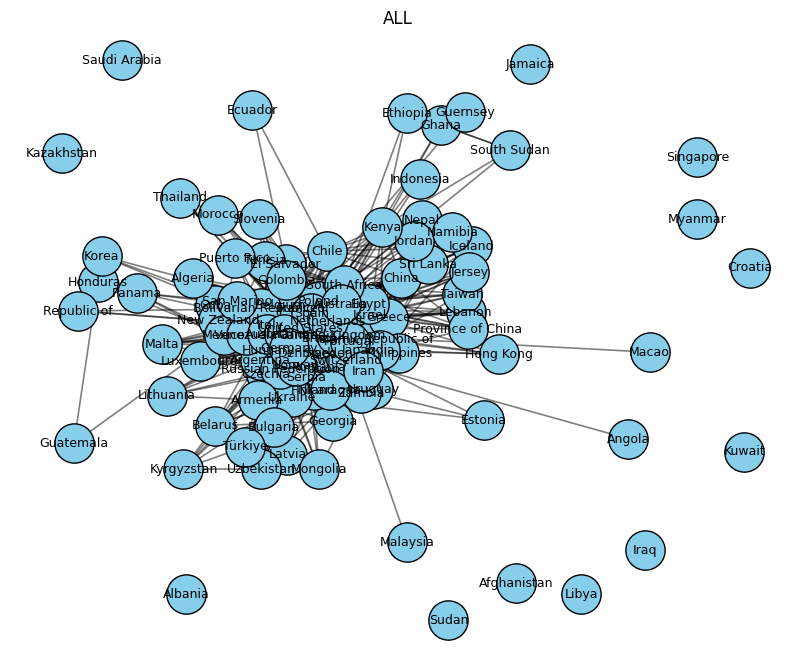

In [20]:
visualize_complementary_graph(complementary(artists, "PaintingsExhibitedAtCountries"), title = "ALL", label = True)

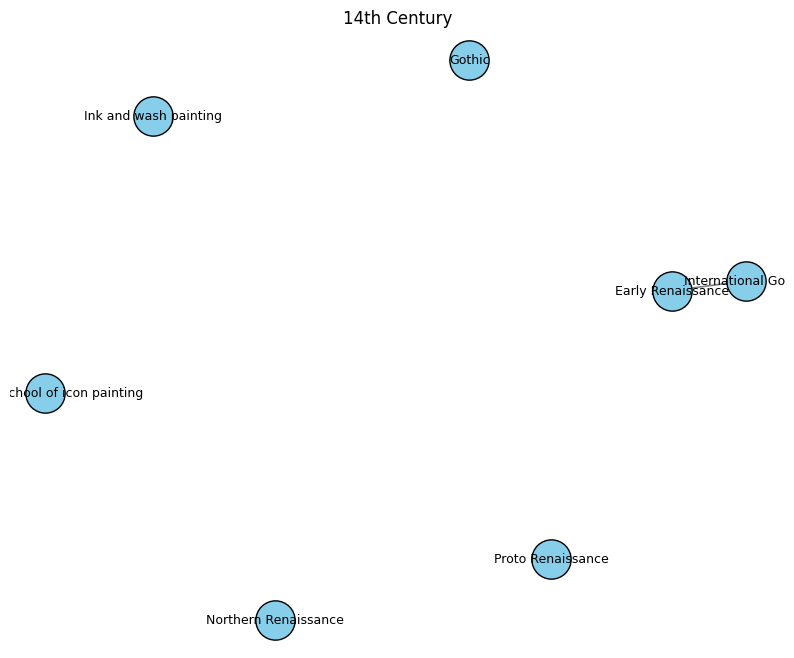

In [21]:
visualize_complementary_graph(complementary(artists_14c, "styles"), title = "14th Century", label = True)

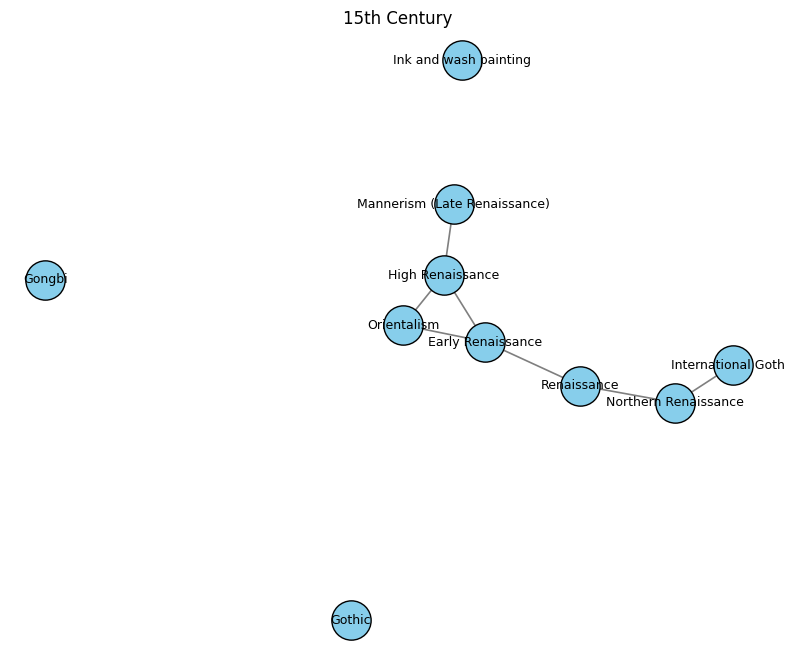

In [22]:
visualize_complementary_graph(complementary(artists_15c, "styles"), title = "15th Century", label = True)

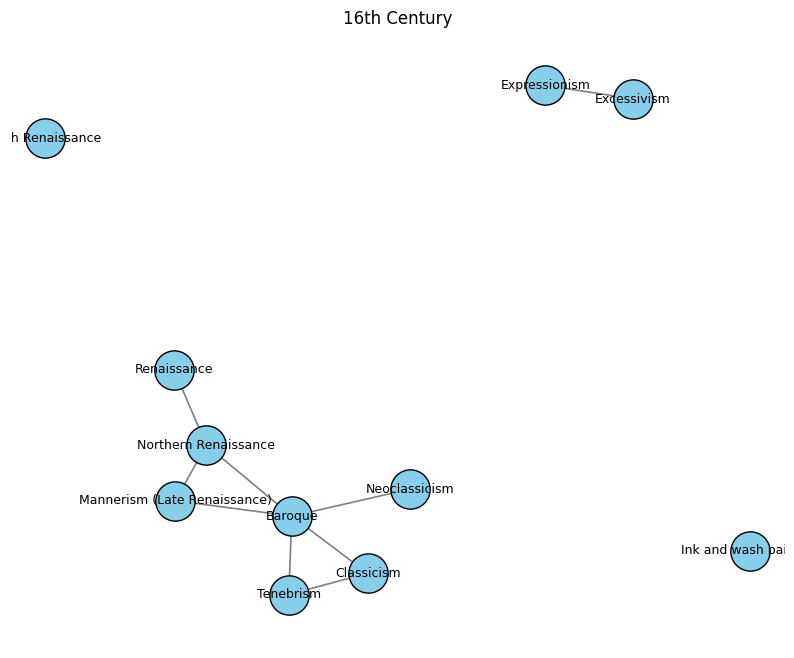

In [23]:
visualize_complementary_graph(complementary(artists_16c, "styles"), title = "16th Century", label = True)

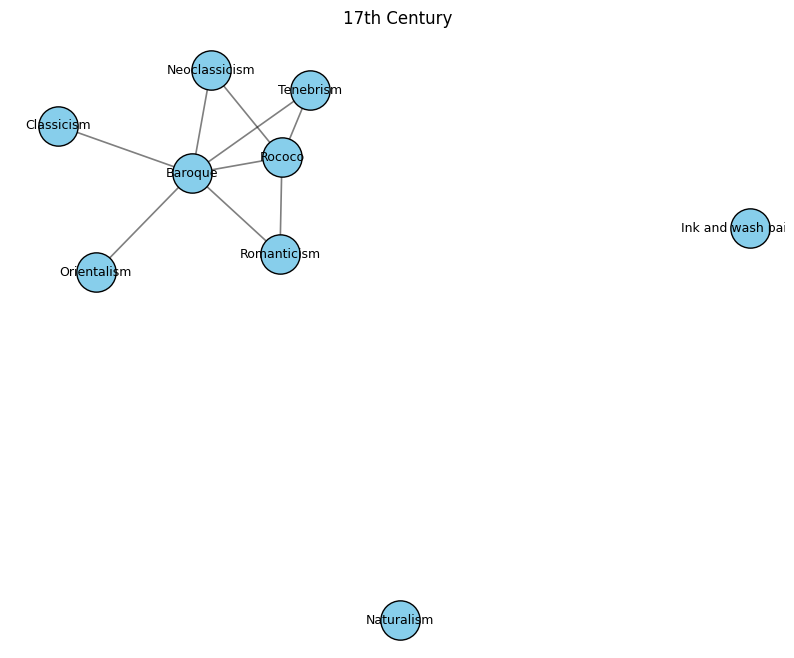

In [24]:
visualize_complementary_graph(complementary(artists_17c, "styles"), title = "17th Century", label = True)

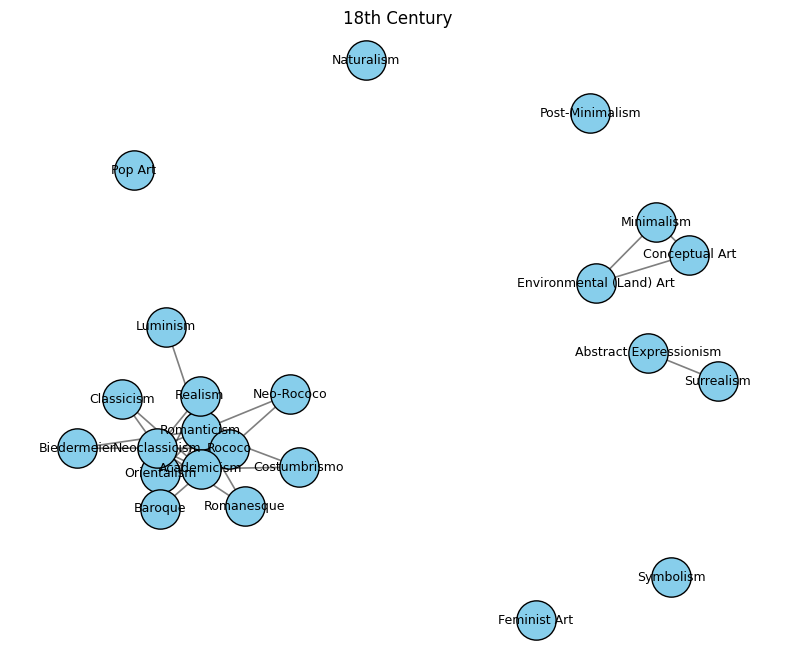

In [25]:
visualize_complementary_graph(complementary(artists_18c, "styles"), title = "18th Century", label = True)

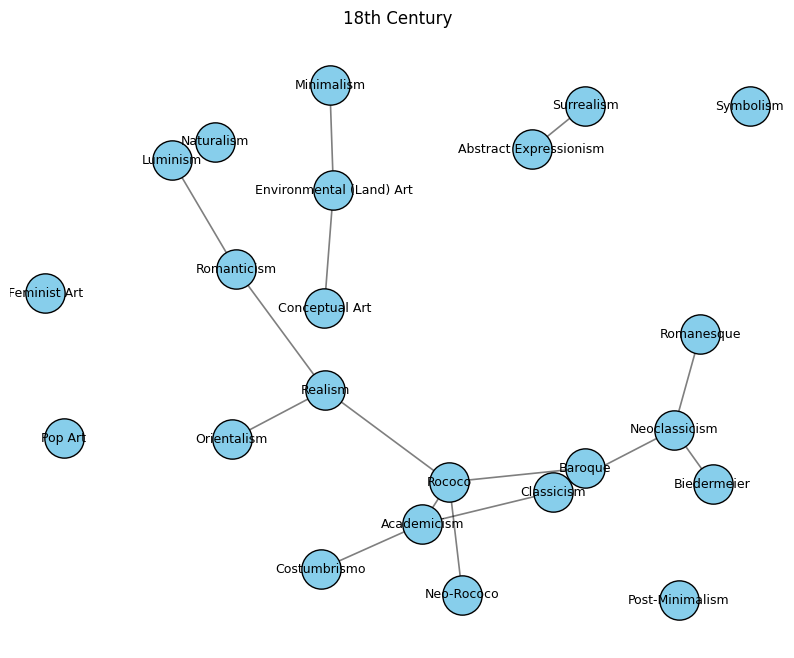

In [26]:
visualize_complementary_graph(skeletonize_graph(complementary(artists_18c, "styles")), title = "18th Century", label = True)

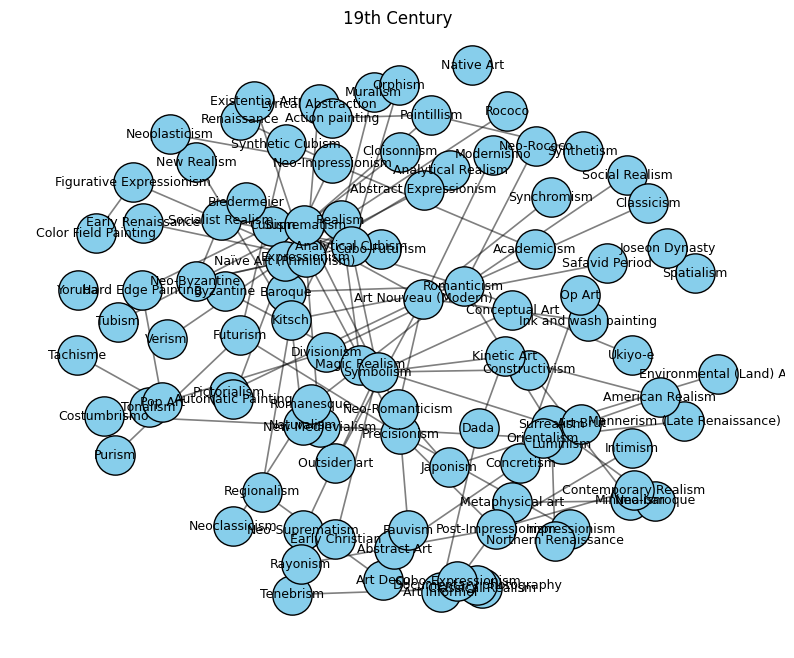

In [27]:
visualize_complementary_graph(skeletonize_graph(complementary(artists_19c, "styles")), title = "19th Century", label = True)

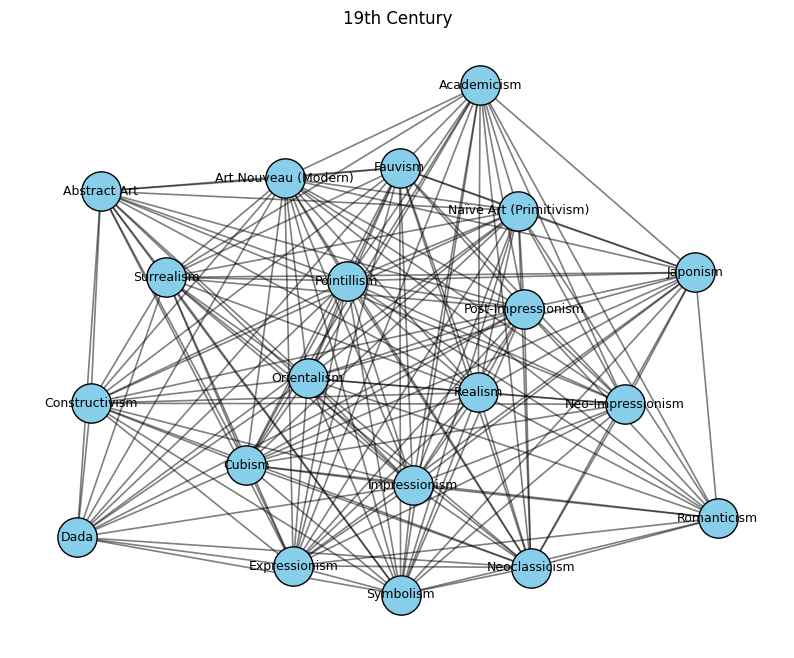

In [28]:
visualize_complementary_graph(complementary_top(artists_19c, "styles"), title = "19th Century", label = True)

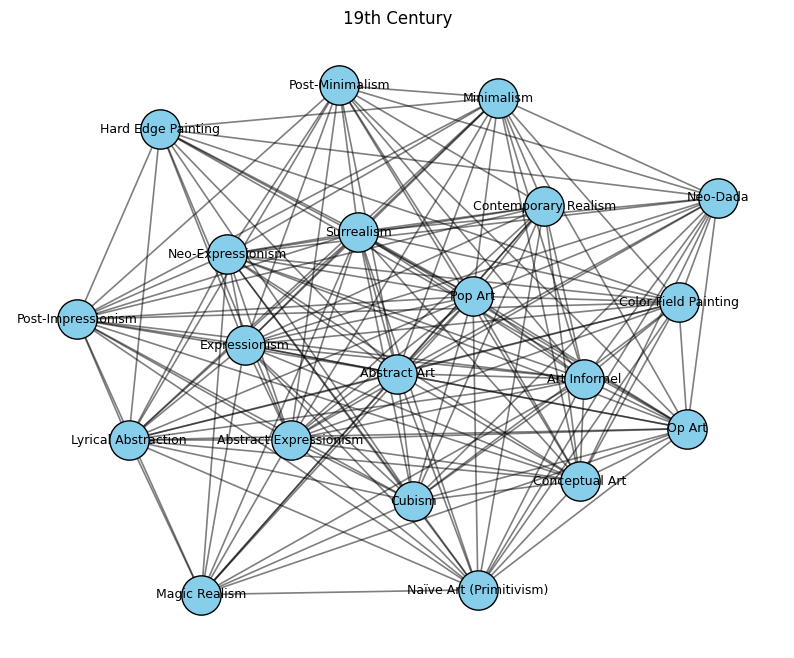

In [29]:
visualize_complementary_graph(complementary_top(artists_20c, "styles"), title = "19th Century", label = True)

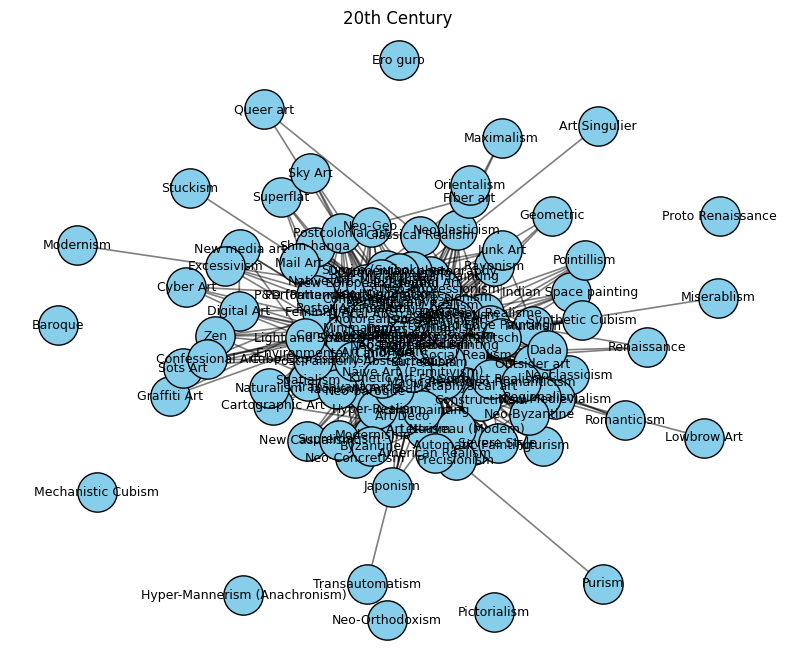

In [30]:
visualize_complementary_graph(complementary(artists_20c, "styles"), title = "20th Century", label = True)

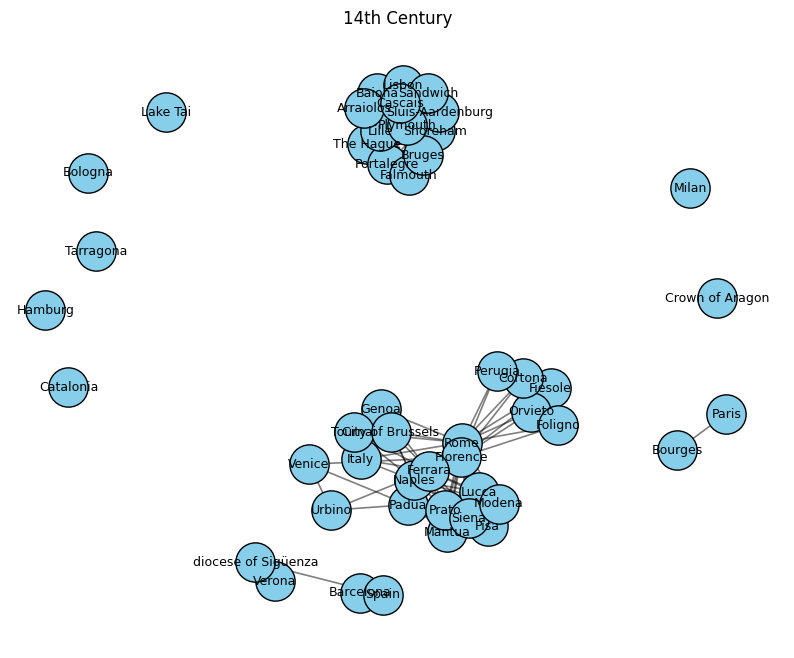

In [31]:
visualize_complementary_graph(complementary(artists_14c, "locations"), title = "14th Century", label = True)

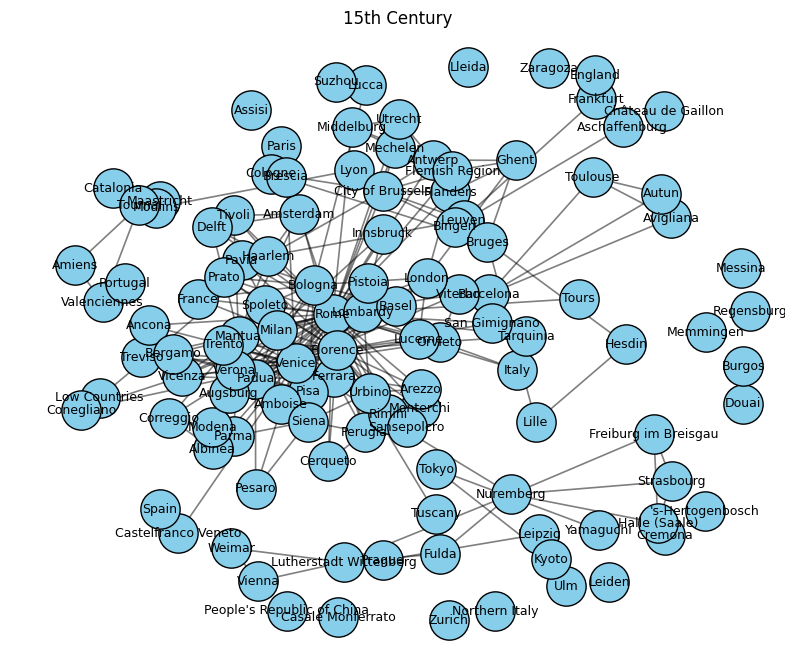

In [32]:
visualize_complementary_graph(complementary(artists_15c, "locations"), title = "15th Century", label = True)

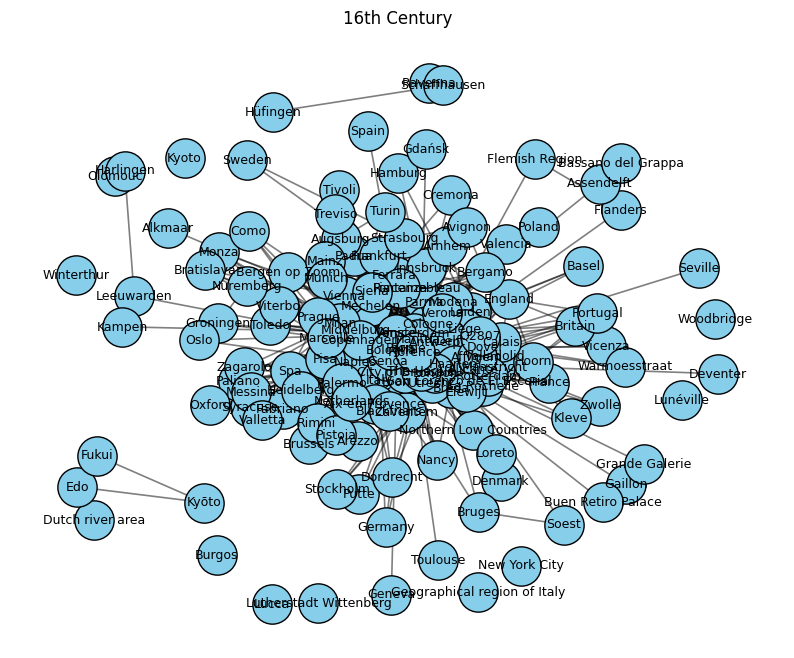

In [33]:
visualize_complementary_graph(complementary(artists_16c, "locations"), title = "16th Century", label = True)

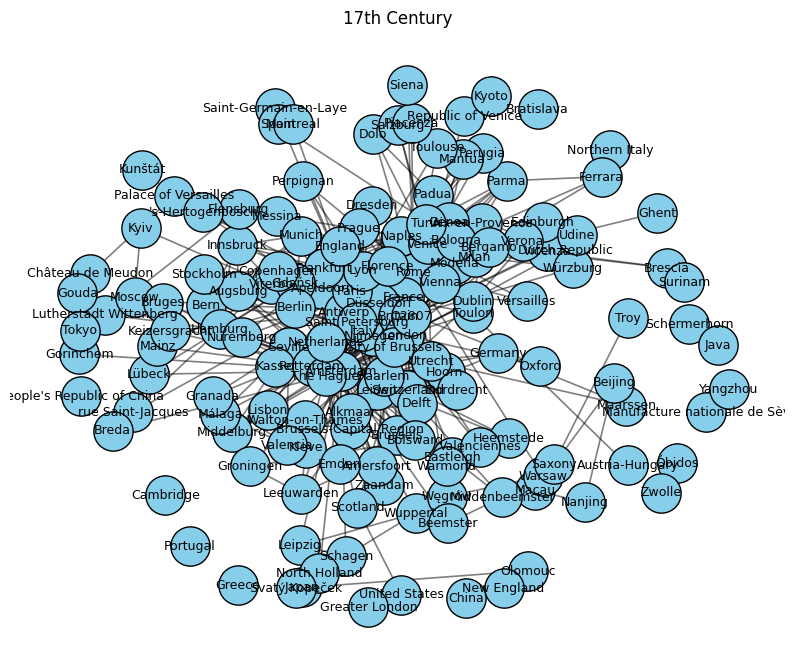

In [34]:
visualize_complementary_graph(complementary(artists_17c, "locations"), title = "17th Century", label = True)

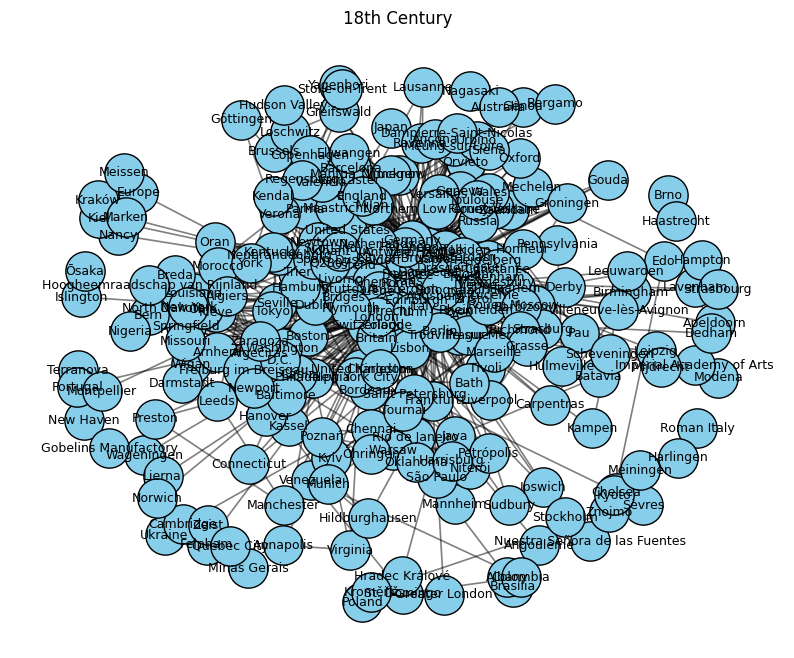

In [35]:
visualize_complementary_graph(complementary(artists_18c, "locations"), title = "18th Century", label = True)

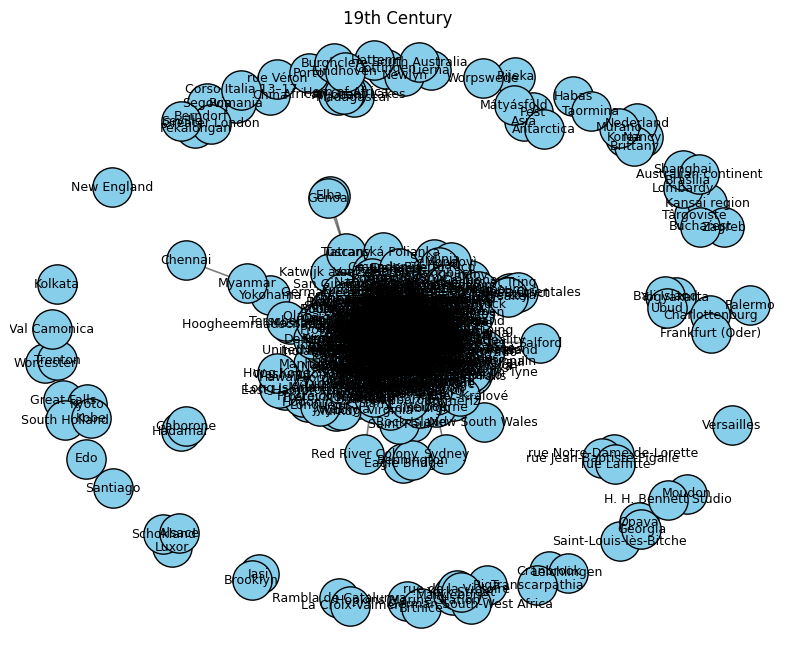

In [36]:
visualize_complementary_graph(complementary(artists_19c, "locations"), title = "19th Century", label = True)